# FLIM Analysis of EGFP and Maroon: Isolated Protein and Transiently Expressed in U2OS

## Loading Necessary Script

In [3]:
import os
import sys
import io
import numpy as np
import scipy.optimize as optimize
import matplotlib.pyplot as plt

from matplotlib import rcParams
%config InlineBackend.figure_format='retina'
rcParams['figure.figsize'] = (16, 12)
rcParams['legend.fontsize']  = 16
rcParams['axes.labelsize'] = 16

import pq_decoding_functions as pq
import flim_fitting_functions as fit

## EGFP
### Transient Expression


Assigned photons to pixels.
 16.562210348840665 % of photons were out of range... Total: 7014717 of 42353749 photons.


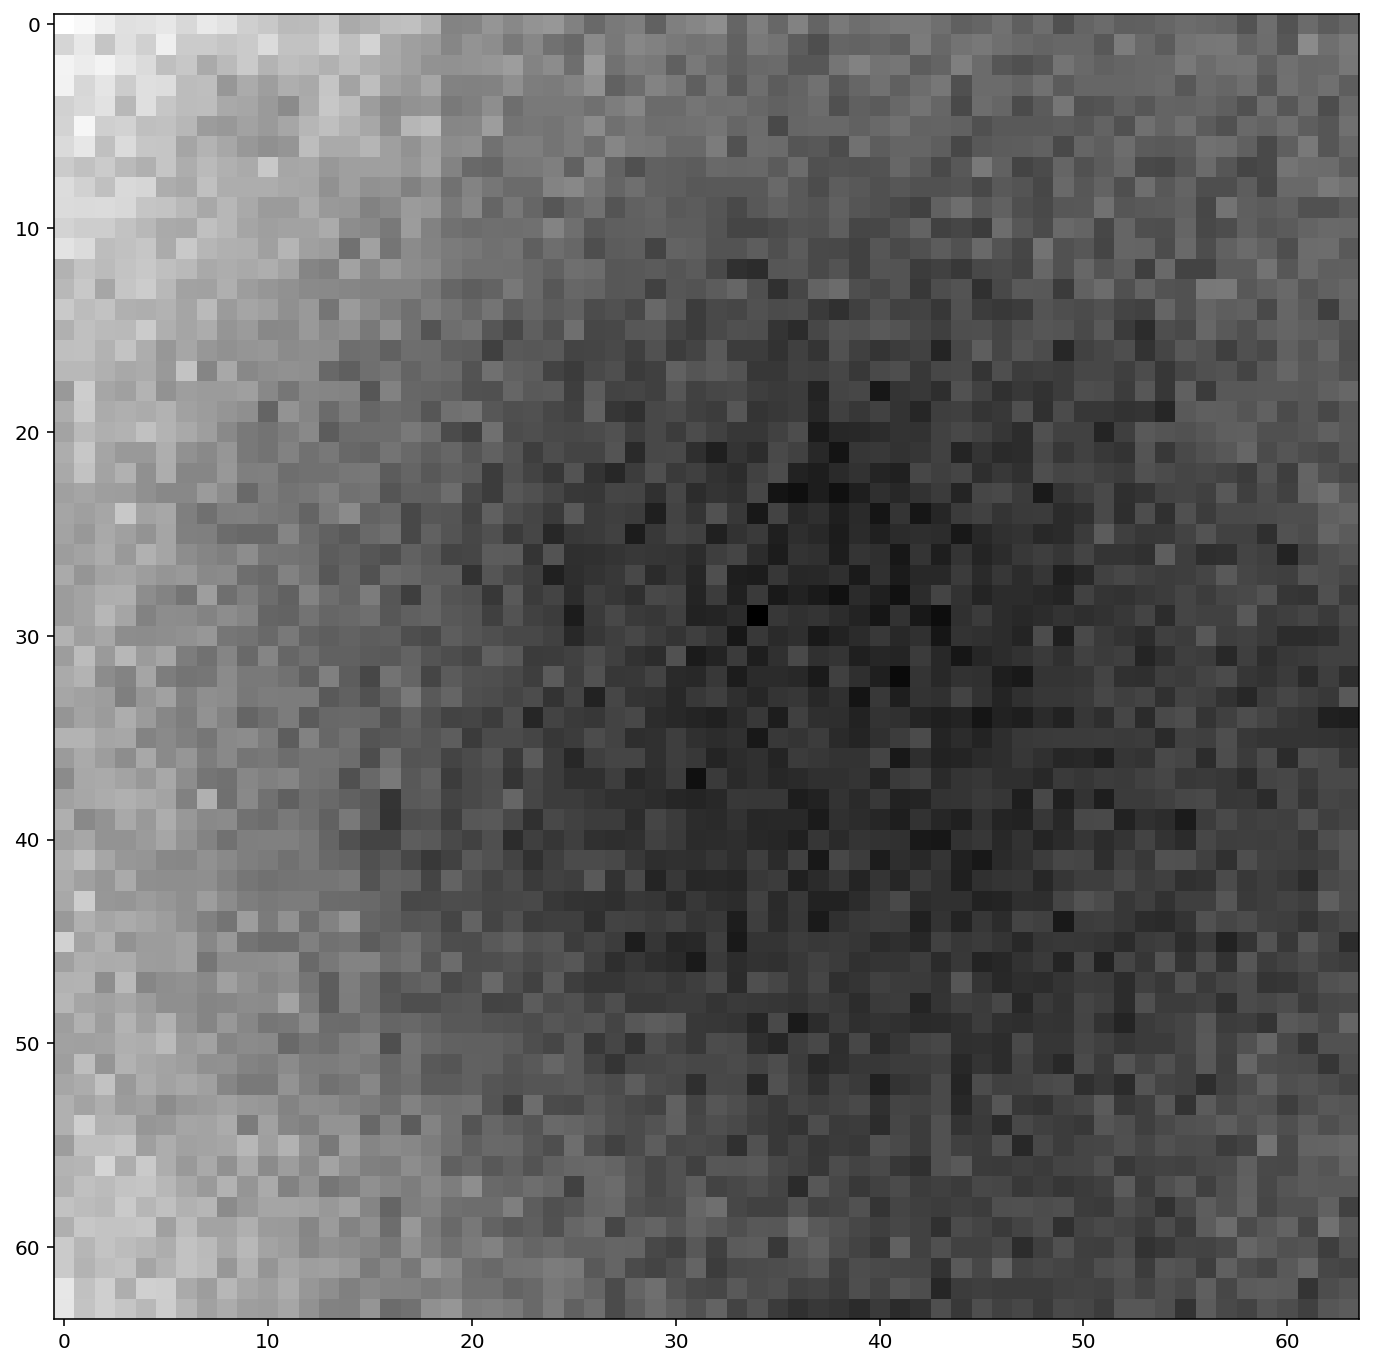

In [124]:
EGFP_cell_data, EGFP_cell_meta = pq.readPTUData(
    path = '../../../FLIM Data/Praktikum_Biochemie/raw_data/IsolatedFP_200310_EGFP_Maroon.sptw/iFP_200310_Kontrolle_Sulforhodamine_10µM_1_2_1.ptu'
)


EGFP_cell_flimarray, EGFP_image = pq.buildFLIMArray(
    recordarray = EGFP_cell_data,
    channel = 1,
    linesinfile = pq.countLines(EGFP_cell_data),
    pixelsx = EGFP_cell_meta['PixelsX'],
    pixelsy = EGFP_cell_meta['PixelsY'],
    globRes = EGFP_cell_meta['GlobalResolution'],
    timeRes = EGFP_cell_meta['Resolution'],
    spatialBinning = 3,
    temporalBinning = 1
)

plt.imshow(EGFP_image, cmap = 'gray')
plt.show()

In [125]:
time_axis = fit.make_time_axis(
    EGFP_cell_meta['GlobalResolution'],
    EGFP_cell_meta['Resolution'],
    EGFP_cell_flimarray.shape[2]
)

EGFP_decay = fit.sum_up_decay(EGFP_cell_flimarray)

In [130]:
parameter_names, estimated_parameters, parameter_bounds = fit.make_start_parameters(
    #offset = 50,
    #amplitude = 500000,
    IRF_scatter = 5000000
)

EGFP_fit = fit.fit_decay(
    EGFP_decay,
    time_axis,
    estimated_parameters,
    parameter_bounds,
    cutoff = 50
)



Reduced Chi-Squared: 18557.788406154108


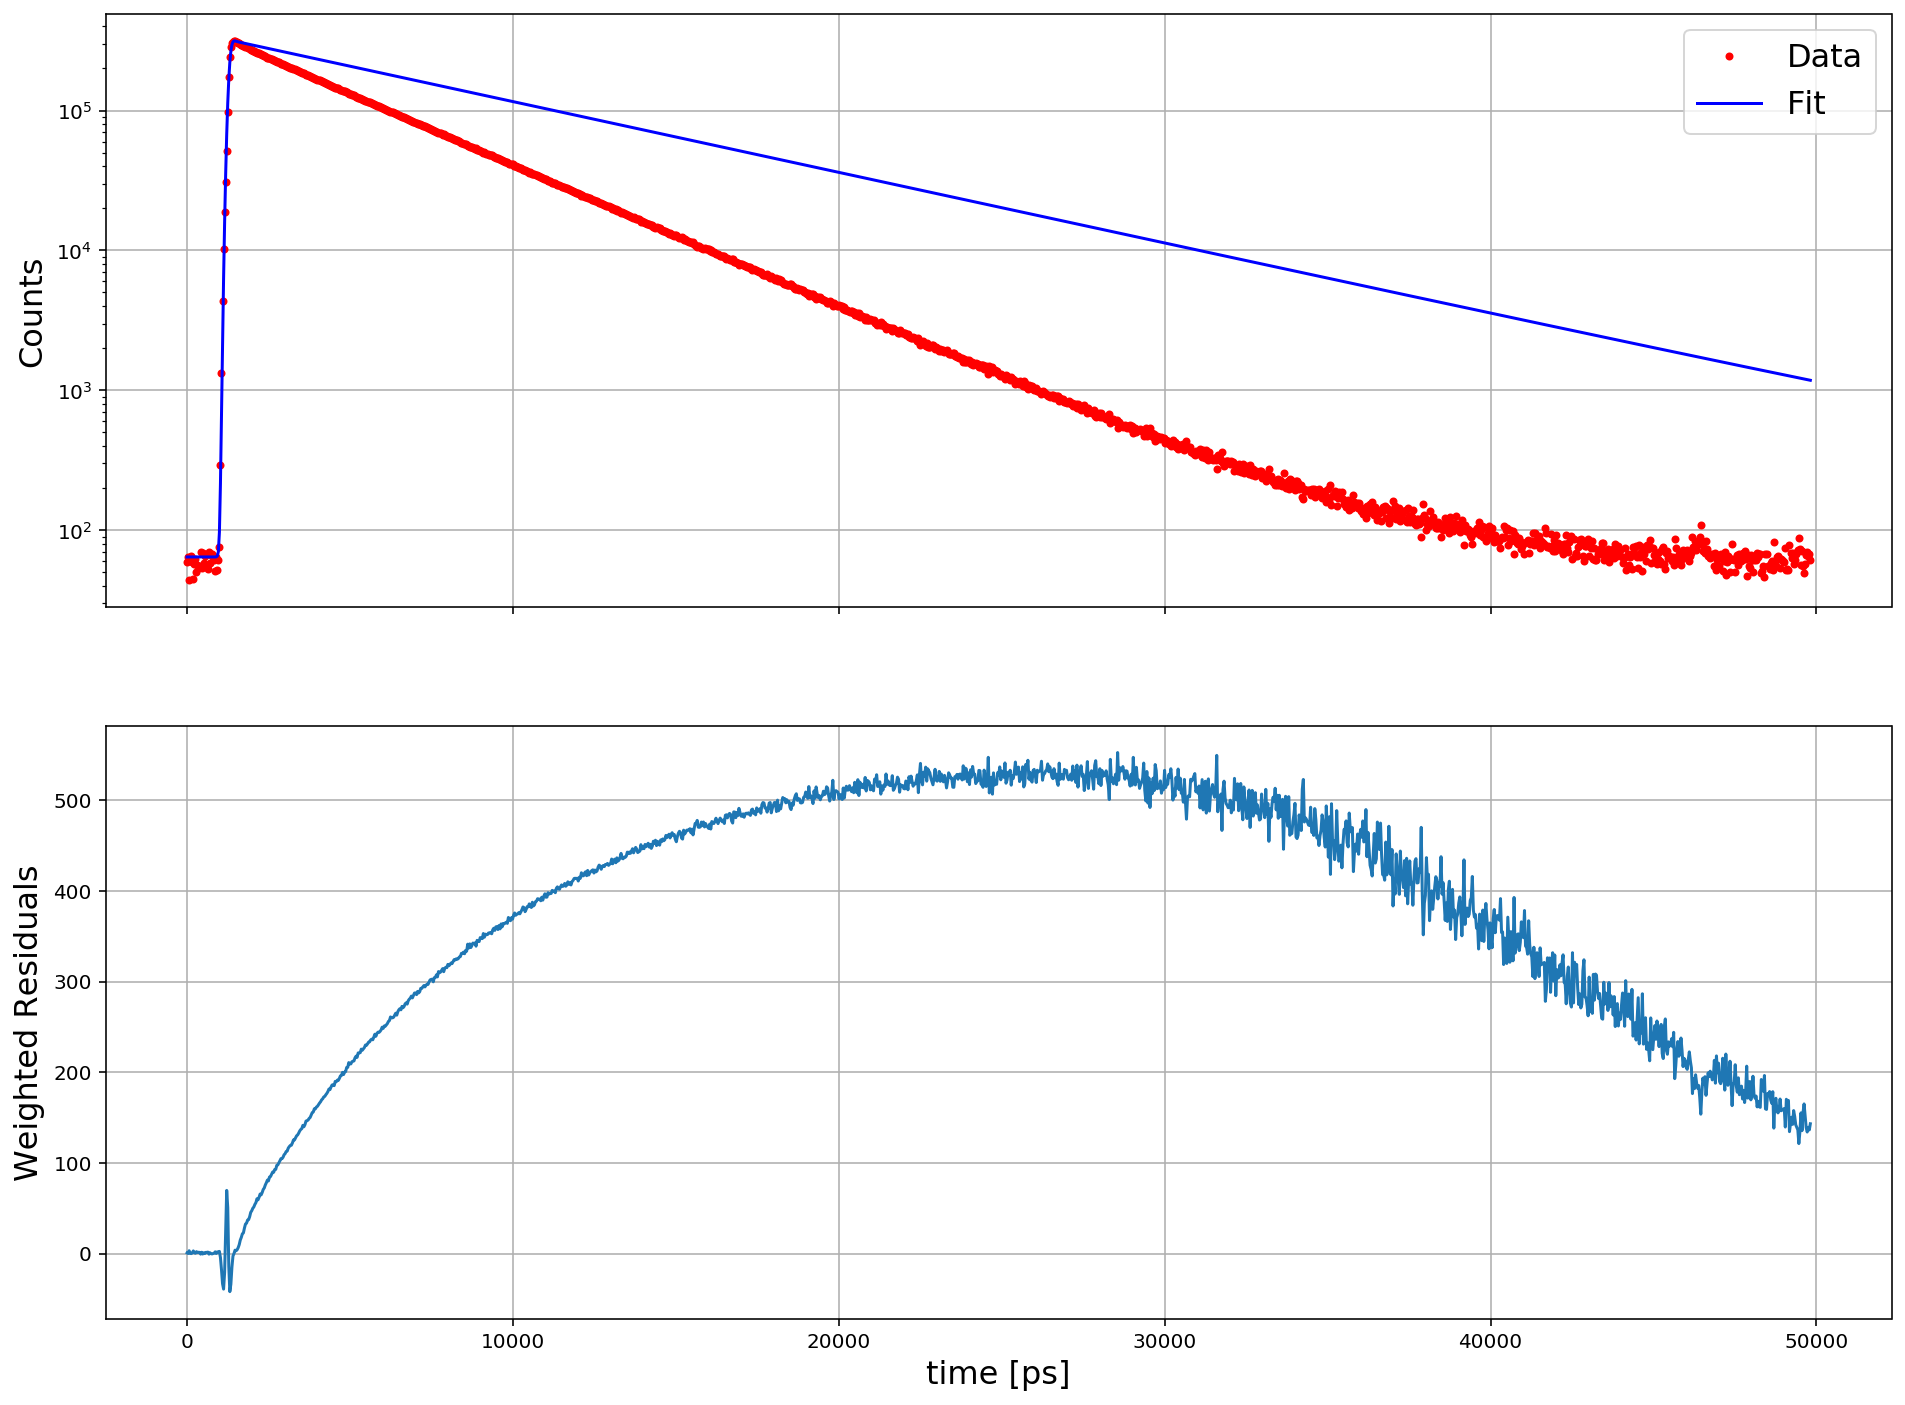

offset 		 64.32910583544127
amplitude 		 7208160.527313069
tau 		 8575.938435391863
IRF_mu 		 1315.7563366675606
IRF_sigma 		 56.84203044024193
IRF_scatter 		 6165693.463440166


In [131]:
fit.plot_fit(EGFP_decay, time_axis, EGFP_fit, cutoff = 50, scale = 'log')
for i in range(0, len(parameter_names)):
    print(parameter_names[i], '\t\t', EGFP_fit['x'][i])